In [39]:
import sys

sys.path.append("/home/arota/Match/")
import os
import torch
import yaml
from dotmap import DotMap
from dataset import CHOLEC80, SCARED, STEREOMIS
from pipelines.odometry.odometry import OdometryPipeline
from pipelines.depth.depth import DepthPipeline
from pipelines.matching.matching import MatchingPipeline
from pipelines.geometry.geometry import GeometryPipeline
from pipelines.depth.tsdf import TSDFVolume
import matplotlib.pyplot as plt
from utilities.visualization import rgb, panelize
from utilities.visualization import viewComparePixelMatches, viewEpipolarGeometry

import numpy as np
from dotenv import load_dotenv
from rich import print

load_dotenv()
%load_ext autoreload
%autoreload 2
CONFIG_PATH = "config_train.yaml"
with open(CONFIG_PATH, "r") as f:
    config_yaml = yaml.safe_load(f)
    config_parameters = config_yaml["parameters"]
    config_training_dict = {
        k: v.get("value") for k, v in config_parameters.items() if v is not None
    }
    config = DotMap(config_training_dict)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
cholec = CHOLEC80(
    path="/home/shared/nearmrs/arota/CHOLEC80/videos",
    vids=["test_*"],
    # exclude=["val_"],
    fps=80,
    frameskip=[1],
    random_pose=False,
    height=config.IMAGE_HEIGHT,
    width=config.IMAGE_WIDTH,
    with_depth=False,
    unit_translation=False,
    with_intrinsics=False,
    with_paths=False,
    crop_zoom_factor=1.2,
)
scared = SCARED(
    path="/home/shared/nearmrs/arota/SCARED",
    vids=["test_*"],
    # exclude=["val_"],
    frameskip=[10],
    fps=10,
    random_pose=False,
    height=config.IMAGE_HEIGHT,
    width=config.IMAGE_WIDTH,
    with_depth=False,
    unit_translation=False,
    with_intrinsics=False,
    with_paths=False,
)
stereomis = STEREOMIS(
    path="/home/shared/nearmrs/arota/StereoMIS_Tracking",
    vids=["test_*"],
    # exclude=["val_"],
    frameskip=[10],
    fps=10,
    random_pose=False,
    height=config.IMAGE_HEIGHT,
    width=config.IMAGE_WIDTH,
    with_depth=False,
    unit_translation=False,
    with_intrinsics=False,
    with_paths=False,
)

SCARED: 463 batches

STEREOMIS: 39 batches

CHOLEC80: 285 batches

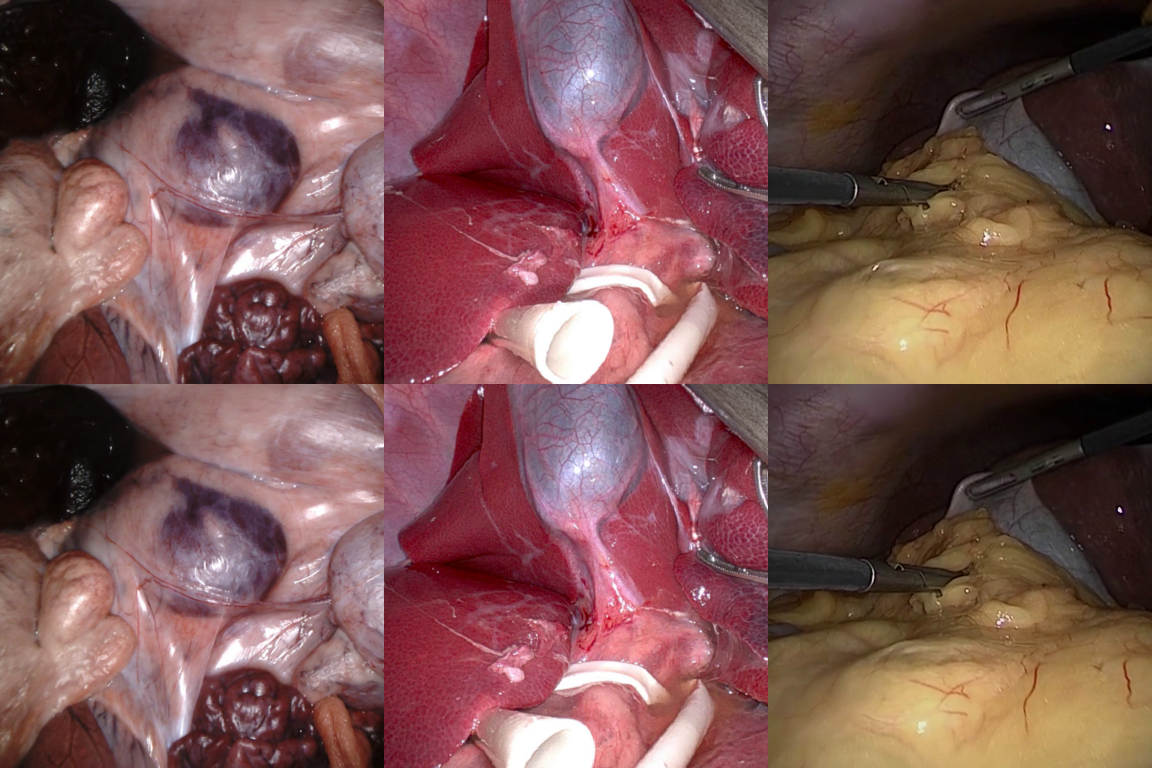

In [3]:
scared_loader = torch.utils.data.DataLoader(
    scared, batch_size=1, sampler=scared.sampler, drop_last=True
)
print(f"SCARED: {len(scared_loader)} batches")
stereomis_loader = torch.utils.data.DataLoader(
    stereomis, batch_size=1, sampler=stereomis.sampler, drop_last=True
)
print(f"STEREOMIS: {len(stereomis_loader)} batches")
cholec_loader = torch.utils.data.DataLoader(
    cholec, batch_size=1, sampler=cholec.sampler, drop_last=True
)
print(f"CHOLEC80: {len(cholec_loader)} batches")
scared_sample = next(iter(scared_loader))["framestack"]
stereomis_sample = next(iter(stereomis_loader))["framestack"]
cholec_sample = next(iter(cholec_loader))["framestack"]

rgb(
    panelize(
    panelize(
        rgb(scared_sample[:, 0], True,resize=(384//1,384//1)),
        rgb(stereomis_sample[:, 0], True,resize=(384//1,384//1)),
        rgb(cholec_sample[:, 0], True,resize=(384//1,384//1)),
    ),
    panelize(
        rgb(scared_sample[:, 1], True,resize=(384//1,384//1)),
        rgb(stereomis_sample[:, 1], True,resize=(384//1,384//1)),
        rgb(cholec_sample[:, 1], True,resize=(384//1,384//1)),
    ),
    mode="vertical",
    )
)

In [4]:
for image, dataset in zip(
    [scared_sample[:, 0], stereomis_sample[:, 0], cholec_sample[:, 0]],
    ["scared", "stereomis", "cholec"],
):
    print(dataset)

    print(image.shape)
    print(image.min(), image.max())

scared

torch.Size([1, 3, 384, 384])

tensor(0.0100) tensor(1.)

stereomis

torch.Size([1, 3, 384, 384])

tensor(0.) tensor(1.)

cholec

torch.Size([1, 3, 384, 384])

tensor(0.) tensor(0.9339)

In [35]:
CONFIG_PATH = "config_train.yaml"
with open(CONFIG_PATH, "r") as f:
    config_yaml = yaml.safe_load(f)
    config_parameters = config_yaml["parameters"]
    config_training_dict = {
        k: v.get("value") for k, v in config_parameters.items() if v is not None
    }
    config = DotMap(config_training_dict)
# config.TRIPLETS_TO_MINE = 64
dataset = CHOLEC80(
    path="/home/shared/nearmrs/arota/CHOLEC80/videos",
    vids=["test_*"],
    # exclude=["val_"],
    frameskip=[1],
    fps=80,
    random_pose=True,
    random_pose_ranges=[2.5, 3.25],
    height=config.IMAGE_HEIGHT,
    width=config.IMAGE_WIDTH,
    with_depth=False,
    unit_translation=False,
    with_intrinsics=False,
    with_paths=False,
    crop_zoom_factor=1.2,
)
len(dataset)

dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=8, sampler=dataset.sampler, drop_last=True
)
iloader = iter(dataloader)
sample = next(iloader)
# Print sample keys and shapes
for k, v in sample.items():
    if hasattr(v, "shape"):
        print(f"{k}: Tensor of shape {list(v.shape)}")
    else:
        print(f"{k}: {type(v)}")

# Initialize device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize Geometry Pipeline (for depth + normals + intrinsics)
geometryPipeline = GeometryPipeline(
    geometry_model_name="Ruicheng/moge-2-vits-normal",
    device=device,
    height=config.IMAGE_HEIGHT,
    width=config.IMAGE_WIDTH,
    return_normalized_depth=True,
)
print("✓ GeometryPipeline initialized")

# Initialize Matching Pipeline (includes the backbone model)
matchingPipeline = MatchingPipeline(
    config=config,
    model=None,  # Will create new model from scratch
    device=device,
)
print(f"✓ MatchingPipeline initialized")
print(f"  - Patch size: {matchingPipeline.patch_size}")
print(f"  - Embedding dim: {matchingPipeline.embed_dim}")
print(f"  - Sequence length: {matchingPipeline.seq_len}")

# Initialize Loss Function
from losses import TripletLoss

loss_fn = TripletLoss()
print("✓ Loss function initialized")
matchingPipeline.model.fromArtifact(
    pth_namestring="/home/arota/Match/checkpoints/weights_best.pt"
)
matchingPipeline.model.eval()
# Extract tensors from sample
framestack = sample["framestack"].to(device)  # [B, T, C, H, W]
if sample.get("Ts2t") is not None:
    camera_pose_gt = sample["Ts2t"].to(device)  # [B, 6]
else:
    camera_pose_gt = None
batch_size = framestack.shape[0]

# print(f"Framestack shape: {framestack.shape}")
# print(f"Camera pose GT shape: {camera_pose_gt.shape}")
# print(f"Batch size: {batch_size}")


# Handle intrinsics if available
if sample.get("intrinsics") is not None:
    K = sample["intrinsics"].to(device)
    # print(f"Intrinsics shape: {K.shape}")
else:
    K = None
    # print("No intrinsics in sample, will be inferred by geometry pipeline")

# Handle fundamental matrix if available
if sample.get("fundamental") is not None:
    fundamental_gt = sample["fundamental"].to(device)
    # print(f"Fundamental GT shape: {fundamental_gt.shape}")
else:
    fundamental_gt = torch.zeros(batch_size, 3, 3, device=device)
    # print("No fundamental matrix in sample, using dummy")
# Compute depth and intrinsics using MoGe-2
depthstack, _, K_moge = geometryPipeline.compute_geometry(framestack)

# Use inferred intrinsics if not provided in sample
if sample.get("intrinsics") is None:
    K = K_moge[:, 0]  # Use intrinsics from first frame

# Rescale depth to meaningful range
depthstack = depthstack * config.DEPTH_SCALE_FACTOR + config.DEPTH_BIAS_FACTOR

# print(f"Depthstack shape: {depthstack.shape}")
# print(f"Intrinsics K shape: {K.shape}")
# print(f"Depth range: [{depthstack.min().item():.3f}, {depthstack.max().item():.3f}]")
# print(f"Intrinsics sample (batch 0):\n{K[0]}")
# import augmentation as aug

# # Apply geometric augmentation (disabled for debugging, set p=0.0)
# # Set p to config value if you want to test with augmentation
# framestack_aug, camera_pose_aug, depthstack_aug = aug.geometric_augmentation(
#     framestack.clone(),
#     camera_pose_gt.clone(),
#     depthstack.clone(),
#     p=0.0,  # Set to 0.0 for debugging, use config.AUGMENTATION_PROBABILITY["GEOMETRIC"] for training
# )

# gt_output = matchingPipeline.synthethize_ground_truth(
#     framestack_aug,
#     K,
#     camera_pose_aug,
#     depthstack_aug[:, 0],  # Use depth of first frame (source)
# )

# warped = gt_output["warped"]
# source_matched_points = gt_output["source_matched_points"]
# target_matched_points_true = gt_output["target_matched_points_true"]
# embedding_mask = gt_output["embedding_mask"]

# # print(f"Warped image shape: {warped.shape}")
# # print(f"Source matched points shape: {source_matched_points.shape}")
# # print(f"GT shape: {target_matched_points_true.shape}")
# # print(f"Embedding mask shape: {embedding_mask.shape}")

# # Create synthetic framestack with warped target image
# synthetic_framestack = framestack_aug.clone()
# synthetic_framestack[:, 1] = warped.clone()

# # print(f"Synthetic framestack shape: {synthetic_framestack.shape}")

# # Apply color augmentation (disabled for debugging, set p=0.0)
# synthetic_framestack_aug, camera_pose_final = aug.color_augmentation(
#     synthetic_framestack.clone(),
#     camera_pose_aug.clone(),
#     p=0.0,  # Set to 0.0 for debugging, use config.AUGMENTATION_PROBABILITY["COLOR"] for training
#     target_only=True,
# )

# # print(f"Synthetic framestack after color aug: {synthetic_framestack_aug.shape}")
# # print(f"Camera pose (final) shape: {camera_pose_final.shape}")
# descriptors = matchingPipeline.model(synthetic_framestack_aug)


idx: Tensor of shape [8]

framestack: Tensor of shape [8, 2, 3, 384, 384]

Ts2t: Tensor of shape [8, 6]

frameskip: Tensor of shape [8]

fundamental: Tensor of shape [8, 1, 3, 3]

...

✓ MatchingPipeline initialized

- Patch size: 16

- Embedding dim: 768

- Sequence length: 576

✓ Loss function initialized

In [36]:
sample = next(iter(torch.utils.data.DataLoader(dataset, batch_size=1, sampler=dataset.sampler, drop_last=True)))
sample.keys()

dict_keys(['idx', 'framestack', 'Ts2t', 'frameskip', 'fundamental'])

In [37]:
from typing import Any


metrics_dataset = {}
from tqdm import tqdm
import augmentation as aug
matchingPipeline.model.eval()
for sample in tqdm(dataloader):
    framestack = sample["framestack"].cuda()
    depthstack, _, K_moge = geometryPipeline.compute_geometry(framestack)
    framestack_aug, camera_pose_aug, depthstack_aug = aug.geometric_augmentation(
        framestack.clone(),
        camera_pose_gt.clone(),
        depthstack.clone(),
        p=0.0,  # Set to 0.0 for debugging, use config.AUGMENTATION_PROBABILITY["GEOMETRIC"] for training
    )
    gt_output = matchingPipeline.synthethize_ground_truth(
        framestack_aug,
        K,
        camera_pose_aug,
        depthstack_aug[:, 0],  # Use depth of first frame (source)
    )
    warped = gt_output["warped"]
    source_matched_points = gt_output["source_matched_points"]
    target_matched_points_true = gt_output["target_matched_points_true"]
    embedding_mask = gt_output["embedding_mask"]


    # # Create synthetic framestack with warped target image
    synthetic_framestack = framestack_aug.clone()
    synthetic_framestack[:, 1] = warped.clone()


    # Apply color augmentation (disabled for debugging, set p=0.0)
    synthetic_framestack_aug, camera_pose_final = aug.color_augmentation(
        synthetic_framestack.clone(),
        camera_pose_aug.clone(),
        p=0.0,  # Set to 0.0 for debugging, use config.AUGMENTATION_PROBABILITY["COLOR"] for training
        target_only=True,
    )

    # print(f"Synthetic framestack after color aug: {synthetic_framestack_aug.shape}")
    # print(f"Camera pose (final) shape: {camera_pose_final.shape}")
    descriptors = matchingPipeline.model(synthetic_framestack_aug)
    # descriptors = matchingPipeline.model(framestack)
    correspondences = matchingPipeline.compute_correspondences(
        descriptors,
        synthetic_framestack_aug,
        # embedding_mask,
    )

    source_pixels_matched = correspondences["source_pixels_matched"]
    target_pixels_matched = correspondences["target_pixels_matched"]
    batch_idx_match = correspondences["batch_idx_match"]
    descriptor_scores = correspondences["descriptor_scores"]
    refinement_scores = correspondences["refinement_scores"]
    sim_matrix = correspondences["sim_matrix"]

    ransac_output = matchingPipeline.RANSAC(
        source_pixels_matched,
        target_pixels_matched,
        batch_idx_match,
    )

    fundamental_pred = ransac_output["F"]
    inliers = ransac_output["inliers"]
    epipolar_scores = ransac_output["scores"]

    scores = matchingPipeline.combine_scores(
        descriptor_scores,
        refinement_scores,
        epipolar_scores,
        config.SCORE_WEIGHTS,
    )

    gt_output_eval = matchingPipeline.synthethize_ground_truth(
        synthetic_framestack_aug,
        K,
        camera_pose_final,
        depthstack_aug[:, 0],
        source_pixels_matched,
        batch_idx_match,
    )

    warped_eval = gt_output_eval["warped"]
    source_pixels_matched_eval = gt_output_eval["source_matched_points"]
    true_pixels_matched = gt_output_eval["target_matched_points_true"]
    embedding_mask_eval = gt_output_eval["embedding_mask"]

    source_pixels_matched = source_pixels_matched[inliers]
    target_pixels_matched = target_pixels_matched[inliers]
    true_pixels_matched = true_pixels_matched[inliers]
    batch_idx_match = batch_idx_match[inliers]
    scores = scores[inliers]

    # Compute pixel error
    # pixel_error = torch.norm(target_pixels_matched - true_pixels_matched, p=2, dim=1)
    metrics = matchingPipeline.compute_metrics(
        source_pixels_matched,
        target_pixels_matched,
        true_pixels_matched,
        batch_idx_match,
        scores,
        fundamental_pred,
        fundamental_gt,
    )
    
    for m, v in metrics.items():
        if m not in metrics_dataset:
            metrics_dataset[m] = []
        metrics_dataset[m].append(v)
for m, v in metrics_dataset.items():
    metrics_dataset[m] = torch.tensor(v)

100%|█████████████████████████████████████████████████████| 35/35 [02:02<00:00,  3.49s/it]


In [38]:
metrics_dataset["EpipolarError"],metrics_dataset["EpipolarError"].mean()

(tensor([0.1038, 0.1115, 0.0798, 0.1045, 0.1445, 0.0620, 0.0522, 0.0411, 0.1038,
         0.1041, 0.1323, 0.2421, 0.0684, 0.1046, 0.1267, 0.0511, 0.0536, 0.0349,
         0.0998, 0.0836, 0.1157, 0.0794, 0.1541, 0.0804, 0.1313, 0.0559, 0.1576,
         0.1228, 0.0842, 0.2199, 0.1694, 0.1412, 0.1362, 0.1441, 0.0834]),
 tensor(0.1080))

In [26]:
len(scores)

512

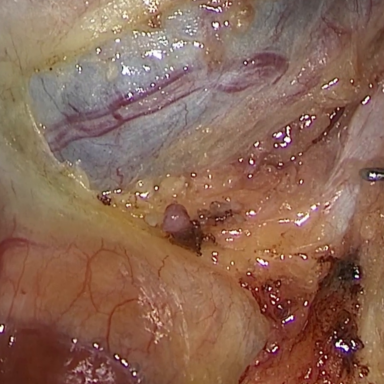

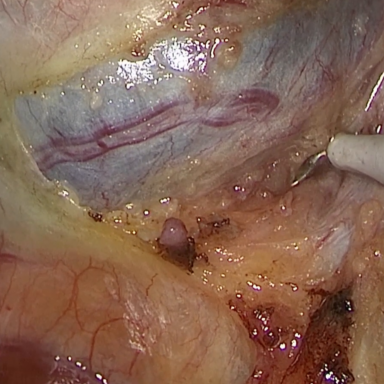

In [ ]:
rgb

In [ ]:
    from pipelines.matching.metrics import epipolar_error

    # Compute epipolar error per match using the predicted fundamental matrix
    epipolar_error_per_match = epipolar_error(
        source_pixels_matched,
        target_pixels_matched,
        fundamental_pred,  # or fundamental_gt if you want to use GT
        batch_idx_match,
        reduction="none",
    )  # Shape: (N,)

    # Define epipolar error range to visualize [min_error, max_error] in pixels
    epipolar_range = (-1,1000)  # Change this to visualize different ranges

    # Create epipolar error range filter
    epipolar_filter = (epipolar_error_per_match >= epipolar_range[0]) & (
        epipolar_error_per_match < epipolar_range[1]
    )

    # Combine with batch filter
    batch_idx_to_visualize = 0
    batch_filter = batch_idx_match == batch_idx_to_visualize
    combined_filter = batch_filter & epipolar_filter

    # Print stats for the filtered matches
    n_total = batch_filter.sum().item()
    n_filtered = combined_filter.sum().item()
    print(f"Epipolar error range: [{epipolar_range[0]:.2f}, {epipolar_range[1]:.2f}) px")
    print(f"Matches in batch {batch_idx_to_visualize}: {n_total}")
    print(f"Matches in range: {n_filtered} ({100 * n_filtered / max(n_total, 1):.1f}%)")
    print(
        f"Epipolar error stats (filtered): min={epipolar_error_per_match[combined_filter].min().item():.3f}, max={epipolar_error_per_match[combined_filter].max().item():.3f}, mean={epipolar_error_per_match[combined_filter].mean().item():.3f}"
    )

    # Visualize pixel matches
    topk = 50
    rgb(
        panelize(
            viewComparePixelMatches(
                img1=framestack[batch_idx_to_visualize, 0],
                img2=framestack[batch_idx_to_visualize, 1],
                pts1=source_pixels_matched[combined_filter],
                pts2=target_pixels_matched[combined_filter],
                pts2_true=true_pixels_matched[combined_filter],
                scores=scores[combined_filter],
                topk=topk,
                use_actual_topk=True,
                non_random_colors=True,
            ),
            viewEpipolarGeometry(
                img1=framestack[batch_idx_to_visualize, 0],
                img2=framestack[batch_idx_to_visualize, 1],
                pts1=source_pixels_matched[combined_filter],
                pts2=target_pixels_matched[combined_filter],
                scores=scores[combined_filter],
                F=fundamental_pred[batch_idx_to_visualize],
                topk=min(topk, combined_filter.sum().item()),
                use_actual_topk=True,
                non_random_colors=True,
            ),
            mode="vertical",
        )
    )

In [47]:
matchingPipeline.config.PATCH_MATCHING_SCORE_THRESHOLD = 0.975
matchingPipeline.config.PIXEL_MATCHING_SCORE_THRESHOLD = 0.15
matchingPipeline.config.MIN_MATCHES_TO_COLLECT = 64
matchingPipeline.config.MAX_EPIPOLAR_DISTANCE = 2
matchingPipeline.config.REFINEMENT_AREA = 4
matchingPipeline.config.SCORES_ALPHA = 0.25


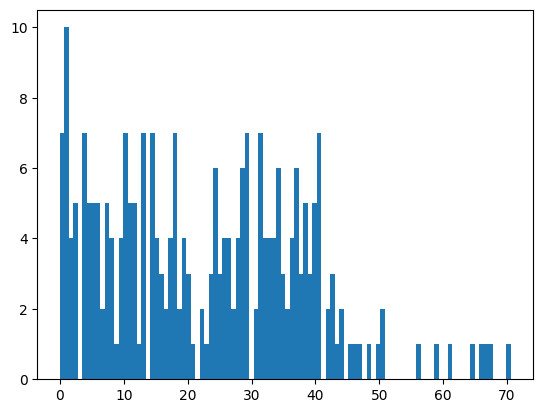

In [22]:
import pipelines.matching.metrics as metr

epipolar = metr.epipolar_error(
    source_pixels_matched.cpu(),
    target_pixels_matched.cpu(),
    fundamental_gt.cpu(),
    batch_idx_match.cpu(),
    reduction="none",
)
plt.hist(epipolar.cpu().numpy(), bins=100)
plt.show()
# epipolar

In [ ]:
source_pixels_matched[inliers].shape

In [ ]:
matchingPipeline.config.RESAMPLED_PATCH_SIZE

In [ ]:
matchingPipeline.config.PATCH_MATCHING_SCORE_THRESHOLD = 0.975
matchingPipeline.config.PIXEL_MATCHING_SCORE_THRESHOLD = 0.15
matchingPipeline.config.MIN_MATCHES_TO_COLLECT = 32
matchingPipeline.config.MAX_EPIPOLAR_DISTANCE = 2
matchingPipeline.config.REFINEMENT_AREA = 16
matchingPipeline.config.SCORES_ALPHA = 0.25


In [23]:
matchingPipeline.config.MAX_EPIPOLAR_DISTANCE

1

In [ ]:
# print(f"Source DINOv2-Features shape: {descriptors['source_embedding'].shape}")
# print(f"Target DINOv2-Features shape: {descriptors['target_embedding'].shape}")
# print(f"Source learned desctiptor shape: {descriptors['source_embedding_match'].shape}")
# print(f"Target learned desctiptor shape: {descriptors['target_embedding_match'].shape}")
# Mine triplets (anchor, positive, negative) for training


# print(f"Loss value: {loss_value:.6f}")

# print(f"Average Anchor-Positive distance: {d_ap:.4f}")
# print(f"Average Anchor-Negative distance: {d_an:.4f}")
# print(f"Distance margin: {d_an - d_ap:.4f}")
# Compute pixel correspondences between frames
correspondences = matchingPipeline.compute_correspondences(
    descriptors,
    synthetic_framestack_aug,
    embedding_mask,
)

source_pixels_matched = correspondences["source_pixels_matched"]
target_pixels_matched = correspondences["target_pixels_matched"]
batch_idx_match = correspondences["batch_idx_match"]
descriptor_scores = correspondences["descriptor_scores"]
refinement_scores = correspondences["refinement_scores"]
sim_matrix = correspondences["sim_matrix"]

# print(f"Source pixels matched shape: {source_pixels_matched.shape}")
# print(f"Target pixels matched shape: {target_pixels_matched.shape}")
# print(f"Batch indices shape: {batch_idx_match.shape}")
# print(f"Number of matches: {len(source_pixels_matched)}")
# print(f"Descriptor scores shape: {descriptor_scores.shape}")
# print(f"Refinement scores shape: {refinement_scores.shape}")
# print(f"Similarity matrix shape: {sim_matrix.shape}")
# Estimate fundamental matrix using RANSAC
ransac_output = matchingPipeline.RANSAC(
    source_pixels_matched,
    target_pixels_matched,
    batch_idx_match,
)

fundamental_pred = ransac_output["F"]
inliers = ransac_output["inliers"]
epipolar_scores = ransac_output["scores"]

# print(f"Fundamental matrix predicted shape: {fundamental_pred.shape}")
# print(f"Inliers shape: {inliers.shape}")
# print(f"Epipolar scores shape: {epipolar_scores.shape}")
# print(f"Number of inliers: {inliers.sum().item()}/{len(inliers)}")
# print(f"Inlier percentage: {100.0 * inliers.sum().item() / len(inliers):.2f}%")
# print(f"Fundamental matrix (batch 0):\n{fundamental_pred[0]}")
# Combine descriptor, refinement, and epipolar scores
scores = matchingPipeline.combine_scores(
    descriptor_scores,
    refinement_scores,
    epipolar_scores,
    config.SCORE_WEIGHTS,
)

# print(f"Combined scores shape: {scores.shape}")
# print(f"Score range: [{scores.min().item():.4f}, {scores.max().item():.4f}]")
# print(f"Mean score: {scores.mean().item():.4f}")
# print(f"Median score: {scores.median().item():.4f}")
# Retrieve pseudo-ground truth for the actual matched pixels
gt_output_eval = matchingPipeline.synthethize_ground_truth(
    synthetic_framestack_aug,
    K,
    camera_pose_final,
    depthstack_aug[:, 0],
    source_pixels_matched,
    batch_idx_match,
)

warped_eval = gt_output_eval["warped"]
source_pixels_matched_eval = gt_output_eval["source_matched_points"]
true_pixels_matched = gt_output_eval["target_matched_points_true"]
embedding_mask_eval = gt_output_eval["embedding_mask"]

## print(f"True pixels matched shape: {true_pixels_matched.shape}")
# # print(
#     f"Number of valid matches: {embedding_mask_eval.sum().int()}/{embedding_mask_eval.numel()} ({100 * embedding_mask_eval.sum().item() / embedding_mask_eval.numel():.2f}%)"
# )

# Compute pixel error
pixel_error = torch.norm(target_pixels_matched - true_pixels_matched, p=2, dim=1)
## print(f"Pixel correspondence error:")
## print(f"  Mean: {pixel_error.mean().item():.2f} pixels")
## print(f"  Median: {pixel_error.median().item():.2f} pixels")
## print(f"  Max: {pixel_error.max().item():.2f} pixels")
# Compute all metrics
metrics = matchingPipeline.compute_metrics(
    matchingPipeline,
    source_pixels_matched,
    target_pixels_matched,
    true_pixels_matched,
    batch_idx_match,
    scores,
    fundamental_pred,
    fundamental_gt,
)
# metricsmatrix[param1, param2, param3, param4, param5, param6] = metrics

# Convert tensors to scalars for display
metrics = {
    k: (v.item() if isinstance(v, torch.Tensor) else v) for k, v in metrics.items()
}

metricsstring = ">>>\n"
for key, value in metrics.items():
    if value is not None:
        metricsstring += f"{key}: {value:.4f}\n"

        # if isinstance(value, float):
        #     print(f"{key}: {value:.4f}")
        # else:
        #     print(f"{key}: {value}")
# Visualize matches for inspection
batch_idx_to_visualize = 0
batch_filter = batch_idx_match == batch_idx_to_visualize
print(metricsstring)
# # Visualize pixel matches
from utilities.visualization import viewComparePixelMatches

viewComparePixelMatches(
    img1=synthetic_framestack_aug[batch_idx_to_visualize, 0],
    img2=synthetic_framestack_aug[batch_idx_to_visualize, 1],
    pts1=source_pixels_matched[batch_filter],
    pts2=target_pixels_matched[batch_filter],
    pts2_true=true_pixels_matched[batch_filter],
    scores=scores[batch_filter],
    topk=50,
    use_actual_topk=True,
)
# break

In [ ]:
# print(f"Framestack shape after augmentation: {framestack_aug.shape}")
# print(f"Camera pose shape after augmentation: {camera_pose_aug.shape}")
# print(f"Depthstack shape after augmentation: {depthstack_aug.shape}")
# print(
# f"Depth range after aug: [{depthstack_aug.min().item():.3f}, {depthstack_aug.max().item():.3f}]"
# )
## Step 5: Synthesize Ground Truth (Warping)
# Synthesize ground truth by warping source to target
PATCH_MATCHING_SCORE_THRESHOLD = [0.90, 0.925, 0.95, 0.975, 0.99]
PIXEL_MATCHING_SCORE_THRESHOLD = [0.10, 0.125, 0.15, 0.175, 0.20]
MIN_MATCHES_TO_COLLECT = [100, 250, 400, 500]
MAX_EPIPOLAR_DISTANCE = [1, 2, 4, 8, 16]
REFINEMENT_AREA = [1, 2, 3, 4]
SCORES_ALPHA = [0.1, 0.175, 0.25, 0.325, 0.4]
metricsmatrix = {}
from itertools import product
from tqdm import tqdm

param_combinations = list(
    product(
        PATCH_MATCHING_SCORE_THRESHOLD,
        PIXEL_MATCHING_SCORE_THRESHOLD,
        MIN_MATCHES_TO_COLLECT,
        MAX_EPIPOLAR_DISTANCE,
        REFINEMENT_AREA,
        SCORES_ALPHA,
    )
)

for param1, param2, param3, param4, param5, param6 in tqdm(
    param_combinations, desc="Grid search"
):
    # print("--------------------------------","\n"
    # ,"PATCH_MATCHING_SCORE_THRESHOLD: ", param1,"\n"
    # ,"PIXEL_MATCHING_SCORE_THRESHOLD: ", param2,"\n"
    # ,"MIN_MATCHES_TO_COLLECT: ", param3,"\n"
    # ,"MAX_EPIPOLAR_DISTANCE: ", param4,"\n"
    # ,"REFINEMENT_AREA: ", param5,"\n"
    # ,"SCORES_ALPHA: ", param6)
    matchingPipeline.config.PATCH_MATCHING_SCORE_THRESHOLD = param1
    matchingPipeline.config.PIXEL_MATCHING_SCORE_THRESHOLD = param2
    matchingPipeline.config.MIN_MATCHES_TO_COLLECT = param3
    matchingPipeline.config.MAX_EPIPOLAR_DISTANCE = param4
    matchingPipeline.config.REFINEMENT_AREA = param5
    matchingPipeline.config.SCORES_ALPHA = param6

    # print(f"Source DINOv2-Features shape: {descriptors['source_embedding'].shape}")
    # print(f"Target DINOv2-Features shape: {descriptors['target_embedding'].shape}")
    # print(f"Source learned desctiptor shape: {descriptors['source_embedding_match'].shape}")
    # print(f"Target learned desctiptor shape: {descriptors['target_embedding_match'].shape}")
    # Mine triplets (anchor, positive, negative) for training

    # print(f"Loss value: {loss_value:.6f}")

    # print(f"Average Anchor-Positive distance: {d_ap:.4f}")
    # print(f"Average Anchor-Negative distance: {d_an:.4f}")
    # print(f"Distance margin: {d_an - d_ap:.4f}")
    # Compute pixel correspondences between frames
    correspondences = matchingPipeline.compute_correspondences(
        descriptors,
        synthetic_framestack_aug,
        embedding_mask,
    )

    source_pixels_matched = correspondences["source_pixels_matched"]
    target_pixels_matched = correspondences["target_pixels_matched"]
    batch_idx_match = correspondences["batch_idx_match"]
    descriptor_scores = correspondences["descriptor_scores"]
    refinement_scores = correspondences["refinement_scores"]
    sim_matrix = correspondences["sim_matrix"]

    # print(f"Source pixels matched shape: {source_pixels_matched.shape}")
    # print(f"Target pixels matched shape: {target_pixels_matched.shape}")
    # print(f"Batch indices shape: {batch_idx_match.shape}")
    # print(f"Number of matches: {len(source_pixels_matched)}")
    # print(f"Descriptor scores shape: {descriptor_scores.shape}")
    # print(f"Refinement scores shape: {refinement_scores.shape}")
    # print(f"Similarity matrix shape: {sim_matrix.shape}")
    # Estimate fundamental matrix using RANSAC
    ransac_output = matchingPipeline.RANSAC(
        source_pixels_matched,
        target_pixels_matched,
        batch_idx_match,
    )

    fundamental_pred = ransac_output["F"]
    inliers = ransac_output["inliers"]
    epipolar_scores = ransac_output["scores"]

    # print(f"Fundamental matrix predicted shape: {fundamental_pred.shape}")
    # print(f"Inliers shape: {inliers.shape}")
    # print(f"Epipolar scores shape: {epipolar_scores.shape}")
    # print(f"Number of inliers: {inliers.sum().item()}/{len(inliers)}")
    # print(f"Inlier percentage: {100.0 * inliers.sum().item() / len(inliers):.2f}%")
    # print(f"Fundamental matrix (batch 0):\n{fundamental_pred[0]}")
    # Combine descriptor, refinement, and epipolar scores
    scores = matchingPipeline.combine_scores(
        descriptor_scores,
        refinement_scores,
        epipolar_scores,
        config.SCORE_WEIGHTS,
    )

    # print(f"Combined scores shape: {scores.shape}")
    # print(f"Score range: [{scores.min().item():.4f}, {scores.max().item():.4f}]")
    # print(f"Mean score: {scores.mean().item():.4f}")
    # print(f"Median score: {scores.median().item():.4f}")
    # Retrieve pseudo-ground truth for the actual matched pixels
    gt_output_eval = matchingPipeline.synthethize_ground_truth(
        synthetic_framestack_aug,
        K,
        camera_pose_final,
        depthstack_aug[:, 0],
        source_pixels_matched,
        batch_idx_match,
    )

    warped_eval = gt_output_eval["warped"]
    source_pixels_matched_eval = gt_output_eval["source_matched_points"]
    true_pixels_matched = gt_output_eval["target_matched_points_true"]
    embedding_mask_eval = gt_output_eval["embedding_mask"]

    ## print(f"True pixels matched shape: {true_pixels_matched.shape}")
    # # print(
    #     f"Number of valid matches: {embedding_mask_eval.sum().int()}/{embedding_mask_eval.numel()} ({100 * embedding_mask_eval.sum().item() / embedding_mask_eval.numel():.2f}%)"
    # )

    # Compute pixel error
    pixel_error = torch.norm(target_pixels_matched - true_pixels_matched, p=2, dim=1)
    ## print(f"Pixel correspondence error:")
    ## print(f"  Mean: {pixel_error.mean().item():.2f} pixels")
    ## print(f"  Median: {pixel_error.median().item():.2f} pixels")
    ## print(f"  Max: {pixel_error.max().item():.2f} pixels")
    # Compute all metrics
    metrics = matchingPipeline.compute_metrics(
        matchingPipeline,
        source_pixels_matched,
        target_pixels_matched,
        true_pixels_matched,
        batch_idx_match,
        scores,
        fundamental_pred,
        fundamental_gt,
    )
    metricsmatrix[param1, param2, param3, param4, param5, param6] = metrics

    # Convert tensors to scalars for display
    metrics = {
        k: (v.item() if isinstance(v, torch.Tensor) else v) for k, v in metrics.items()
    }

    metricsstring = ">>>\n"
    for key, value in metrics.items():
        if value is not None:
            metricsstring += f"{key}: {value:.4f}\n"

            # if isinstance(value, float):
            #     print(f"{key}: {value:.4f}")
            # else:
            #     print(f"{key}: {value}")
    # Visualize matches for inspection
    batch_idx_to_visualize = 0
    batch_filter = batch_idx_match == batch_idx_to_visualize
    # print(metricsstring)
    # # Visualize pixel matches
    from utilities.visualization import viewComparePixelMatches

    viewComparePixelMatches(
        img1=synthetic_framestack_aug[batch_idx_to_visualize, 0],
        img2=synthetic_framestack_aug[batch_idx_to_visualize, 1],
        pts1=source_pixels_matched[batch_filter],
        pts2=target_pixels_matched[batch_filter],
        pts2_true=true_pixels_matched[batch_filter],
        scores=scores[batch_filter],
        topk=50,
        use_actual_topk=True,
    )
    break


In [ ]:
from utilities.visualization import viewEpipolarGeometry

rgb(
    viewComparePixelMatches(
        img1=synthetic_framestack_aug[batch_idx_to_visualize, 0],
        img2=synthetic_framestack_aug[batch_idx_to_visualize, 1],
        pts1=source_pixels_matched[batch_filter],
        pts2=target_pixels_matched[batch_filter],
        pts2_true=true_pixels_matched[batch_filter],
        scores=scores[batch_filter],
        topk=50,
        use_actual_topk=True,
    )
)
rgb(
    viewEpipolarGeometry(
        img1=framestack[batch_idx_to_visualize, 0],
        img2=framestack[batch_idx_to_visualize, 1],
        pts1=source_pixels_matched[batch_filter],
        pts2=target_pixels_matched[batch_filter],
        scores=scores[batch_filter],
        F=fundamental_pred[batch_idx_to_visualize],
        topk=min(50, len(source_pixels_matched[batch_filter])),
        use_actual_topk=True,
    )
)

In [ ]:
import pickle
import pandas as pd
import numpy as np

# Save metricsmatrix to file
save_path = "/home/arota/Match/sandboxes/metricsmatrix.pkl"
with open(save_path, "wb") as f:
    pickle.dump(metricsmatrix, f)
print(f"Saved metricsmatrix to {save_path}")

# Convert to DataFrame for easier analysis
# Parameter names for columns
param_names = [
    "PATCH_MATCHING_SCORE_THRESHOLD",
    "PIXEL_MATCHING_SCORE_THRESHOLD",
    "MIN_MATCHES_TO_COLLECT",
    "MAX_EPIPOLAR_DISTANCE",
    "REFINEMENT_AREA",
    "SCORES_ALPHA",
]

# Build rows: each row = (param1, ..., param6, metric1, metric2, ...)
rows = []
for key, metrics_dict in metricsmatrix.items():
    row = dict(zip(param_names, key))
    for metric_name, metric_val in metrics_dict.items():
        val = metric_val.item() if isinstance(metric_val, torch.Tensor) else metric_val
        row[metric_name] = val
    rows.append(row)

df = pd.DataFrame(rows)
df.to_csv("/home/arota/Match/sandboxes/metricsmatrix.csv", index=False)
print(f"Saved DataFrame to /home/arota/Match/sandboxes/metricsmatrix.csv")
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()
import pickle
import pandas as pd
import numpy as np

# Save metricsmatrix to file
save_path = "/home/arota/Match/sandboxes/metricsmatrix.pkl"
with open(save_path, "wb") as f:
    pickle.dump(metricsmatrix, f)
print(f"Saved metricsmatrix to {save_path}")

# Convert to DataFrame for easier analysis
# Parameter names for columns
param_names = [
    "PATCH_MATCHING_SCORE_THRESHOLD",
    "PIXEL_MATCHING_SCORE_THRESHOLD",
    "MIN_MATCHES_TO_COLLECT",
    "MAX_EPIPOLAR_DISTANCE",
    "REFINEMENT_AREA",
    "SCORES_ALPHA",
]

# Build rows: each row = (param1, ..., param6, metric1, metric2, ...)
rows = []
for key, metrics_dict in metricsmatrix.items():
    row = dict(zip(param_names, key))
    for metric_name, metric_val in metrics_dict.items():
        val = metric_val.item() if isinstance(metric_val, torch.Tensor) else metric_val
        row[metric_name] = val
    rows.append(row)

df = pd.DataFrame(rows)
df.to_csv("/home/arota/Match/sandboxes/metricsmatrix.csv", index=False)
print(f"Saved DataFrame to /home/arota/Match/sandboxes/metricsmatrix.csv")
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()


In [ ]:
import pickle
import pandas as pd
import numpy as np

df = pd.read_csv("/home/arota/Match/sandboxes/pareto/metricsmatrix.csv")
param_names = [
    "PATCH_MATCHING_SCORE_THRESHOLD",
    "PIXEL_MATCHING_SCORE_THRESHOLD",
    "MIN_MATCHES_TO_COLLECT",
    "MAX_EPIPOLAR_DISTANCE",
    "REFINEMENT_AREA",
    "SCORES_ALPHA",
]

In [ ]:
df.EpipolarError.min()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Directory to save Pareto images
outdir = "sandboxes/pareto"
os.makedirs(outdir, exist_ok=True)

# Define all target metrics and their plot colors
target_metrics = [
    "Precision",
    "Recall",
    "AUCPR",
    "EpipolarError",
    "FundamentalError",
    "MDistMean",
]
maximize = [True, True, True, False, False, False]
metric_plot_colors = {
    "Precision": "tab:blue",
    "Recall": "tab:green",
    "AUCPR": "tab:purple",
    "EpipolarError": "tab:red",
    "FundamentalError": "tab:orange",
    "MDistMean": "tab:brown",
}
# For colormap, can use variations if desired, or just stick to viridis/mako etc.

for target_metric, maximize in zip(target_metrics, maximize):
    df_sorted = df.sort_values(target_metric, ascending=not maximize)

    # Print/save best configuration
    best_row = df_sorted.iloc[0]
    best_str = "\n".join([f"  {param}: {best_row[param]:.2f}" for param in param_names])
    best_metric = (
        f"{target_metric}: {best_row[target_metric]:.6f}"
        if isinstance(best_row[target_metric], (float, np.floating))
        else f"{target_metric}: {best_row[target_metric]}"
    )
    print(f"Best configuration for {target_metric}:\n{best_str}\n  {best_metric}\n")

    # Print/save worst configuration
    worst_row = df_sorted.iloc[-1]
    worst_str = "\n".join(
        [f"  {param}: {worst_row[param]:.2f}" for param in param_names]
    )
    worst_metric = (
        f"{target_metric}: {worst_row[target_metric]:.6f}"
        if isinstance(worst_row[target_metric], (float, np.floating))
        else f"{target_metric}: {worst_row[target_metric]}"
    )
    print(f"Worst configuration for {target_metric}:\n{worst_str}\n  {worst_metric}")

    # --- 2. MARGINAL EFFECT OF EACH PARAMETER (averaged over all other params) ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for i, param in enumerate(param_names):
        ax = axes[i]
        grouped = df.groupby(param)[target_metric].agg(["mean", "std"])
        color = metric_plot_colors.get(target_metric, "tab:blue")
        ax.errorbar(
            grouped.index.astype(str),
            grouped["mean"],
            yerr=grouped["std"],
            marker="o",
            capsize=5,
            linewidth=2,
            markersize=8,
            color=color,
        )
        ax.set_xlabel(param, fontsize=10)
        ax.set_ylabel(f"{target_metric} (mean ± std)", fontsize=10)
        ax.set_title(f"Effect of {param}", fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="x", rotation=45)
    plt.suptitle(
        f"Marginal Effect of Each Parameter on {target_metric}",
        fontsize=14,
        fontweight="bold",
        color=metric_plot_colors.get(target_metric, "k"),
    )
    plt.tight_layout()
    outpath = os.path.join(outdir, f"marginal_effects_{target_metric}.png")
    plt.savefig(
        outpath,
        dpi=150,
        bbox_inches="tight",
    )
    plt.close(fig)

    # --- 3. PAIRWISE HEATMAP (2D slices through parameter space) ---
    # Enable if desired: by default commented out, but can be enabled per metric.
    # param_x = "PATCH_MATCHING_SCORE_THRESHOLD"
    # param_y = "SCORES_ALPHA"
    # pivot = df.pivot_table(
    #     values=target_metric, index=param_y, columns=param_x, aggfunc="mean"
    # )
    # plt.figure(figsize=(10, 8))
    # sns.heatmap(
    #     pivot,
    #     annot=False,
    #     fmt=".3f",
    #     cmap="viridis" if maximize else "mako_r",  # Different colormap for each
    # )
    # plt.title(
    #     f"{target_metric} vs {param_x} and {param_y}\n(averaged over other parameters)"
    # )
    # plt.tight_layout()
    # plt.savefig(
    #     os.path.join(outdir, f"pairwise_heatmap_{target_metric}.png"),
    #     dpi=150,
    #     bbox_inches="tight",
    # )
    # plt.close()

    # --- 4. PARALLEL COORDINATES PLOT (view all params + metric together) ---
    from pandas.plotting import parallel_coordinates

    # Normalize parameters to [0,1] for visualization
    df_norm = df.copy()
    for col in param_names:
        df_norm[col] = (df_norm[col] - df_norm[col].min()) / (
            df_norm[col].max() - df_norm[col].min() + 1e-8
        )

    # Bin target metric into categories for coloring
    try:
        df_norm["quality"] = pd.qcut(
            df_norm[target_metric], q=4, labels=["Q1 (worst)", "Q2", "Q3", "Q4 (best)"]
        )
    except Exception:
        df_norm["quality"] = pd.cut(
            df_norm[target_metric],
            bins=4,
            labels=["Q1 (worst)", "Q2", "Q3", "Q4 (best)"],
        )

    import matplotlib as mpl
    from scipy.interpolate import make_interp_spline

    # Add the continuous metric column, normalized to [0,1]
    df_norm["metric_value"] = (
        df_norm[target_metric] - df_norm[target_metric].min()
    ) / (df_norm[target_metric].max() - df_norm[target_metric].min() + 1e-8)

    columns_to_plot = param_names + ["metric_value"]

    # Prepare colors: map metric_value to a colormap
    cmapname = "viridis" if maximize else "mako_r"
    cmap = plt.get_cmap(cmapname)
    norm = mpl.colors.Normalize(
        vmin=df_norm["metric_value"].min(), vmax=df_norm["metric_value"].max()
    )
    colors = cmap(norm(df_norm["metric_value"].values))

    fig, ax = plt.subplots(figsize=(14, 6))

    num_vars = len(columns_to_plot)
    x = np.arange(num_vars)

    # Draw a line per experiment, color by the continuous metric
    for i, row in df_norm.iterrows():
        y = row[columns_to_plot].values.astype(float)
        x_smooth = np.linspace(x.min(), x.max(), num_vars * 10)
        try:
            spline = make_interp_spline(x, y, k=3)
            y_smooth = spline(x_smooth)
            ax.plot(x_smooth, y_smooth, color=colors[i], alpha=0.5, linewidth=1.5)
        except Exception:
            ax.plot(x, y, color=colors[i], alpha=0.5, linewidth=1.5)

    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = plt.colorbar(
        sm, ax=ax, orientation="vertical", label=f"{target_metric} (normalized)"
    )

    # Different text color for each metric
    ax.set_xticks(x)
    ax.set_xticklabels(
        columns_to_plot,
        rotation=45,
        ha="right",
        color=metric_plot_colors.get(target_metric, "k"),
    )
    ax.set_xlim(x.min(), x.max())
    ax.set_title(
        f"Parallel Coordinates: Parameter Combinations with {target_metric} (colormap, last col = {target_metric}, continuous)",
        fontsize=14,
        color=metric_plot_colors.get(target_metric, "k"),
    )
    plt.tight_layout()
    plt.savefig(
        os.path.join(outdir, f"parallel_coords_continuous_{target_metric}.png"),
        dpi=150,
        bbox_inches="tight",
    )
    plt.close(fig)
    RGBììì

print(f"Saved Pareto visualizations for each metric in '{outdir}/'")
plt.show()
plt.show()


In [ ]:
# =============================================================================
# MULTI-OBJECTIVE OPTIMIZATION: Pareto Front Analysis
# =============================================================================

# 5. SCATTER PLOT: Two metrics against each other (find trade-offs)
# -----------------------------------------------------------------------------
metric_x = "Precision"  # Higher is better
metric_y = "EpipolarError"  # Assuming this is epipolar error - lower is better
metric_color = "MDistMean"
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    df[metric_x],
    df[metric_y],
    c=df[metric_color],
    cmap="viridis",
    alpha=0.7,
    s=50,
    edgecolors="k",
    linewidths=0.5,
)
ax.set_xlabel(metric_x, fontsize=12)
ax.set_ylabel(metric_y, fontsize=12)
ax.set_title(f"Trade-off: {metric_x} vs {metric_y} (color = {metric_color})")
plt.colorbar(scatter, label=metric_color)
ax.grid(True, alpha=0.3)

# Mark Pareto-optimal points (max Precision, min Epipolar Error)
pareto_mask = np.ones(len(df), dtype=bool)
for i, (px, py) in enumerate(zip(df[metric_x], df[metric_y])):
    # Point i is dominated if any other point has higher Precision AND lower Epipolar Error
    dominated = (
        (df[metric_x] >= px)
        & (df[metric_y] <= py)
        & ((df[metric_x] > px) | (df[metric_y] < py))
    ).any()
    pareto_mask[i] = not dominated

pareto_df = df[pareto_mask]
ax.scatter(
    pareto_df[metric_x],
    pareto_df[metric_y],
    c="red",
    s=150,
    marker="*",
    edgecolors="darkred",
    linewidths=1,
    label=f"Pareto optimal ({len(pareto_df)} pts)",
    zorder=5,
)

# Find best compromise: highest Precision among Pareto-optimal points
best_idx = pareto_df[metric_x].idxmax()
best_config = pareto_df.loc[best_idx]

ax.scatter(
    best_config[metric_x],
    best_config[metric_y],
    c="gold",
    s=300,
    marker="D",
    edgecolors="black",
    linewidths=2,
    label="Best: Max Precision on Pareto",
    zorder=6,
)

ax.legend()
plt.tight_layout()
plt.savefig(
    "/home/arota/Match/sandboxes/pareto_front.png", dpi=150, bbox_inches="tight"
)
plt.show()

print(f"\nPareto-optimal configurations ({len(pareto_df)}):")
print(
    pareto_df[param_names + [metric_x, metric_y, metric_color]]
    .sort_values(metric_x, ascending=False)
    .to_string(index=False)
)

print(f"\n{'=' * 80}")
print(f"BEST CONFIGURATION (Highest Precision on Pareto Front):")
print(f"{'=' * 80}")
for param in param_names:
    print(f"  {param}: {best_config[param]}")
print(f"\nMetrics:")
print(f"  {metric_x}: {best_config[metric_x]:.4f}")
print(f"  {metric_y}: {best_config[metric_y]:.4f}")
print(f"  {metric_color}: {best_config[metric_color]:.4f}")
print(f"{'=' * 80}\n")

# 6. CORRELATION MATRIX: How metrics relate to each other
# -----------------------------------------------------------------------------
metrics_cols = [c for c in df.columns if c not in param_names]
corr = df[metrics_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Metric Correlation Matrix")
plt.tight_layout()
plt.savefig(
    "/home/arota/Match/sandboxes/metric_correlation.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 7. PARAMETER IMPORTANCE via correlation with metrics
# -----------------------------------------------------------------------------
print(f"\nParameter correlation with {metric_x} (maximize):")
for param in param_names:
    corr_val = df[param].corr(df[metric_x])
    print(f"  {param}: {corr_val:+.4f}")

print(f"\nParameter correlation with {metric_y} (minimize):")
for param in param_names:
    corr_val = df[param].corr(df[metric_y])
    print(f"  {param}: {corr_val:+.4f}")

In [ ]:
# =============================================================================
# RELOAD SAVED DATA (for future sessions)
# =============================================================================
# Uncomment to reload saved metricsmatrix:
# with open("/home/arota/Match/sandboxes/metricsmatrix.pkl", "rb") as f:
#     metricsmatrix = pickle.load(f)

# Or reload from CSV (loses tensor types but easier to work with):
# df = pd.read_csv("/home/arota/Match/sandboxes/metricsmatrix.csv")

# =============================================================================
# QUICK SUMMARY: Find optimal parameters for a weighted combination of metrics
# =============================================================================
# Define weights (positive = maximize, negative = minimize)
weights = {
    "Precision": 1.0,
    "Recall": 0.5,
    "AUCPR": 1.0,
    "EpipolarError": -0.3,  # Negative because lower is better
    "FundamentalError": -0.3,
    "MDistMean": -0.5,
}

# Normalize each metric to [0,1] and compute weighted score
df_score = df.copy()
for metric, w in weights.items():
    if metric in df_score.columns:
        min_val = df_score[metric].min()
        max_val = df_score[metric].max()
        df_score[f"{metric}_norm"] = (df_score[metric] - min_val) / (
            max_val - min_val + 1e-8
        )
        if w < 0:  # For metrics to minimize, invert
            df_score[f"{metric}_norm"] = 1 - df_score[f"{metric}_norm"]

score_cols = [f"{m}_norm" for m in weights.keys() if m in df_score.columns]
weight_vals = np.array(
    [abs(weights[m]) for m in weights.keys() if m in df_score.columns]
)
df_score["weighted_score"] = (df_score[score_cols].values * weight_vals).sum(
    axis=1
) / weight_vals.sum()

# Best configuration
best_idx = df_score["weighted_score"].idxmax()
print("=" * 60)
print("OPTIMAL PARAMETERS (weighted combination of all metrics):")
print("=" * 60)
for param in param_names:
    print(f"  {param}: {df_score.loc[best_idx, param]}")
print(f"\nWeighted Score: {df_score.loc[best_idx, 'weighted_score']:.4f}")
print("\nMetric values for optimal configuration:")
for metric in weights.keys():
    if metric in df_score.columns:
        print(f"  {metric}: {df_score.loc[best_idx, metric]:.4f}")